# This model prevents catastrophic failure in gas turbines by identifying thermal degradation patterns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


# Define column names based on dataset documentation

In [4]:
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# Load training data

In [14]:
import os
from pathlib import Path

data_file = Path('train_FD001.txt')
if not data_file.exists():
    candidates = list(Path.cwd().rglob('train_FD001.txt'))
    if candidates:
        data_file = candidates[0]
    else:
        raise FileNotFoundError(
            f"{data_file} not found in {Path.cwd()}. "
            "Place the file in the notebook directory or update the path."
        )

train = pd.read_csv(data_file, sep=r'\s+', header=None, names=col_names)
print(f"Loaded data from {data_file}")

Loaded data from c:\Users\user\Mechanical Engineering Data Science Projects\CMaps\train_FD001.txt


# Get the maximum cycle for each unit

In [19]:
max_cycle = train.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycle.columns = ['unit_nr', 'max_cycles']

# Merge back to original dataframe

In [35]:
train = train.merge(max_cycle, on=['unit_nr'], how='left')

# Calculate RUL

In [37]:
train['RUL'] = train['max_cycles'] - train['time_cycles']

In [38]:
train.drop('max_cycles', axis=1, inplace=True)

In [39]:
train.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


# Drop sensors with zero standard deviation (constant values)

In [41]:
stats = train.describe().T
constant_sensors = stats[stats['std'] == 0].index.tolist()
train.drop(labels=constant_sensors, axis=1, inplace=True)

In [42]:
if 'setting_3' in train.columns:
    train.drop(['setting_3'], axis=1, inplace=True)

print(f"Dropped constant columns: {constant_sensors}")

Dropped constant columns: ['setting_3', 's_18', 's_19']


# Train the Model

In [43]:
X = train.drop(['unit_nr', 'time_cycles', 'RUL'], axis=1)
y = train['RUL']

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [45]:
model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
model.fit(X_scaled, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

# Quick check on training performance

In [46]:
y_pred = model.predict(X_scaled)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"Training RMSE: {rmse:.2f} cycles")

Training RMSE: 25.36 cycles


Visualizing Sensor Degradation

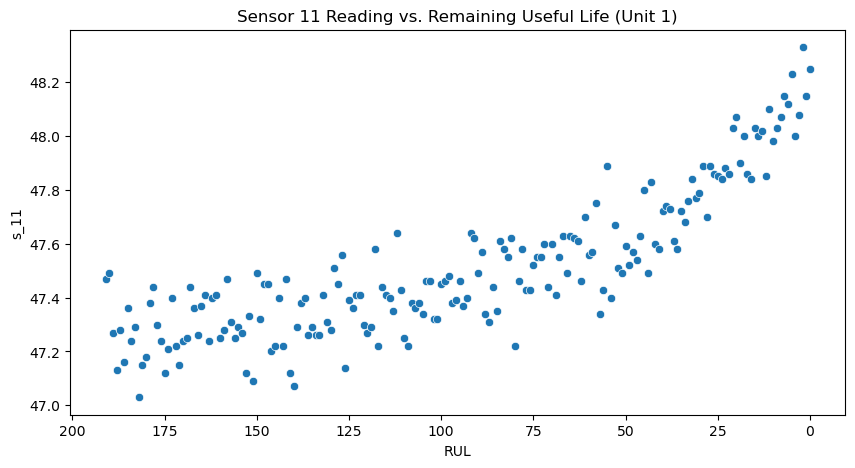

In [47]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=train[train['unit_nr']==1], x='RUL', y='s_11')
plt.title('Sensor 11 Reading vs. Remaining Useful Life (Unit 1)')
plt.gca().invert_xaxis() # Show RUL counting down to zero
plt.show()

# Deployment / Results Summary

In [48]:
def predict_maintenance(sensor_data):
    scaled_input = scaler.transform(sensor_data)
    prediction = model.predict(scaled_input)
    return prediction[0]

In [49]:
sample_engine_data = X.iloc[0:1]
print(f"Predicted RUL: {predict_maintenance(sample_engine_data):.1f} cycles")

Predicted RUL: 169.4 cycles
